In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv(r"C:\Users\Administrator\Documents\1st Project\Processed_data\orders_clean.csv",
parse_dates=['order_purchase_timestamp', 'order_approved_at','order_delivered_carrier_date','order_delivered_customer_date',
'order_estimated_delivery_date'])

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [4]:
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

In [5]:
orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

In [6]:
orders[['order_id', 'delivery_days', 'delivery_delay_days']].head(10)

,order_id,delivery_days,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,-10.0
5,a4591c265e18cb1dcee52889e2d8acc3,16.0,-6.0
6,136cce7faa42fdb2cefd53fdc79a6098,NaN,NaN
7,6514b8ad8028c9f2cc2374ded245783f,9.0,-12.0
8,76c6e866289321a7c93b82b54852dc33,9.0,-32.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,18.0,-7.0


In [7]:
order_items = pd.read_csv(r"C:\Users\Administrator\Documents\1st Project\Processed_data\order_items_clean.csv")

In [8]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
order_items['item_total'] = order_items['price'] + order_items['freight_value']

In [10]:
order_value = order_items.groupby('order_id')['item_total'].sum().reset_index()

In [11]:
order_value = order_value.rename(columns={'item_total': 'order_total_value'})

In [12]:
order_value.head(10)

,order_id,order_total_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
5,00048cc3ae777c65dbb7d2a0634bc1ea,34.59
6,00054e8431b9d7675808bcb819fb4a32,31.75
7,000576fe39319847cbb9d288c5617fa6,880.75
8,0005a1a1728c9d785b8e2b08b904576c,157.60
9,0005f50442cb953dcd1d21e1fb923495,65.39


In [13]:
customers = pd.read_csv(r"C:\Users\Administrator\Documents\1st Project\Processed_data\customers_clean.csv")

In [14]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [15]:
customer_order_counts = customers.groupby('customer_unique_id')['customer_id'].count().reset_index()
customer_order_counts = customer_order_counts.rename(columns={'customer_id': 'total_orders'})

In [16]:
customer_order_counts['is_repeat_customer'] = customer_order_counts['total_orders'] > 1

In [17]:
customer_order_counts.head(10)

,customer_unique_id,total_orders,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,False
2,0000f46a3911fa3c0805444483337064,1,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,False
4,0004aac84e0df4da2b147fca70cf8255,1,False
5,0004bd2a26a76fe21f786e4fbd80607f,1,False
6,00050ab1314c0e55a6ca13cf7181fecf,1,False
7,00053a61a98854899e70ed204dd4bafe,1,False
8,0005e1862207bf6ccc02e4228effd9a0,1,False
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,False


In [18]:
total_customers = len(customer_order_counts)
print(f"Total customers: {total_customers}")

Total customers: 96096


In [19]:
repeat_customers = customer_order_counts['is_repeat_customer'].sum()
print(f"Repeat Customers: {repeat_customers}")

Repeat Customers: 2997


In [20]:
repeat_perc = (repeat_customers / total_customers * 100).round(2)
print(f"Percentage of Repeat Customers: {repeat_perc}%")

Percentage of Repeat Customers: 3.12%


In [22]:
import matplotlib.pyplot as plt

In [23]:
from sqlalchemy import create_engine

username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "cart2insights"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [24]:
query = "SELECT review_score FROM order_reviews"
reviews = pd.read_sql(query, con=engine)

In [25]:
print(reviews['review_score'].value_counts().sort_index())

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


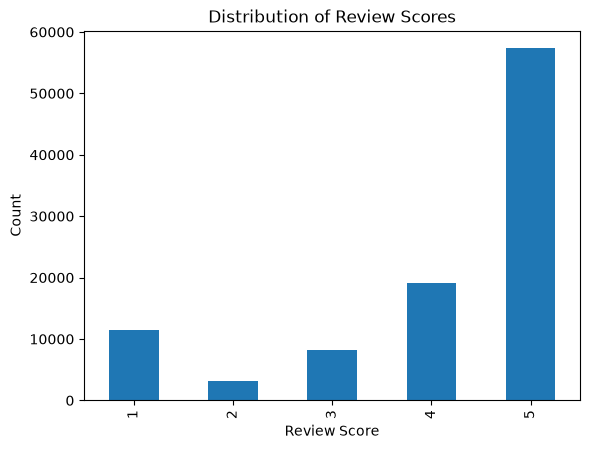

In [ ]:
reviews['review_score'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.title('Distribution of Review Scores')
plt.show()

In [ ]:
query = """SELECT r.review_score, DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) AS delivery_delay_days 
FROM order_reviews r
JOIN orders o ON r.order_id = o.order_id WHERE o.order_delivered_customer_date IS NOT NULL;"""

bivariate_data = pd.read_sql(query, con=engine)
bivariate_data.head()

,review_score,delivery_delay_days
0,5,-9
1,4,-3
2,5,-14
3,4,-6
4,5,-16


   review_score  delivery_delay_days
0             1            -4.060580
1             2            -8.634818
2             3           -10.774052
3             4           -12.380840
4             5           -13.388153


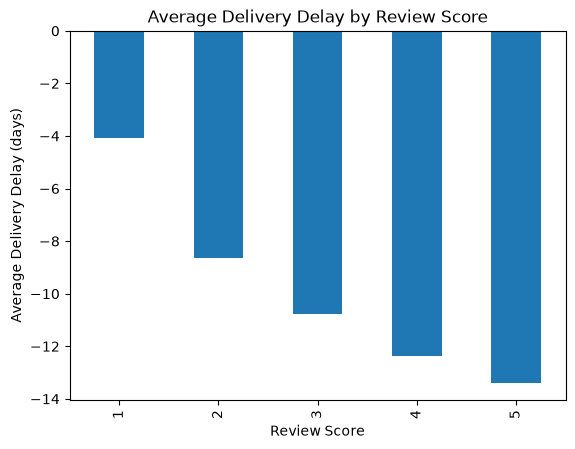

In [ ]:
avg_delay_by_score = bivariate_data.groupby('review_score')['delivery_delay_days'].mean().reset_index()
print(avg_delay_by_score)

avg_delay_by_score.plot(kind='bar', x='review_score', y='delivery_delay_days', legend=False)
plt.title('Average Delivery Delay by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Delay (days)')
plt.show()

In [ ]:
query = """SELECT r.review_score, p.payment_type, DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) AS delivery_delay_days
FROM order_reviews r
JOIN orders o ON r.order_id = o.order_id
JOIN order_payments p ON o.order_id = p.order_id WHERE o.order_delivered_customer_date IS NOT NULL;"""

multivariate_data = pd.read_sql(query, con=engine)
multivariate_data.head()

,review_score,payment_type,delivery_delay_days
0,5,credit_card,-9
1,4,credit_card,-3
2,5,credit_card,-14
3,4,credit_card,-6
4,5,credit_card,-16


In [28]:
pivot = multivariate_data.pivot_table(
values='delivery_delay_days',
index='review_score',
columns='payment_type',
aggfunc='mean')
print(pivot)

payment_type     boleto  credit_card  debit_card    voucher
review_score                                               
1             -3.633133    -4.141825   -5.325000  -5.119718
2             -7.530225    -8.904049   -9.422222  -9.005076
3             -9.875378   -11.042003   -9.965217 -11.718487
4            -11.717601   -12.578621  -11.333333 -12.216090
5            -12.627670   -13.597426  -12.757609 -13.710979


In [29]:
query = """SELECT DATE_FORMAT(o.order_purchase_timestamp, '%%Y-%%m') AS order_month, COUNT(DISTINCT o.order_id) AS total_orders,
SUM(oi.price + oi.freight_value) AS total_revenue
FROM orders o JOIN order_items oi ON o.order_id = oi.order_id GROUP BY order_month ORDER BY order_month;"""

trend_data = pd.read_sql(query, con=engine)
trend_data.head(15)

,order_month,total_orders,total_revenue
0,2016-09,3,354.75
1,2016-10,308,56808.84
2,2016-12,1,19.62
3,2017-01,789,137188.49
4,2017-02,1733,286280.62
5,2017-03,2641,432048.59
6,2017-04,2391,412422.24
7,2017-05,3660,586190.95
8,2017-06,3217,502963.04
9,2017-07,3969,584971.62


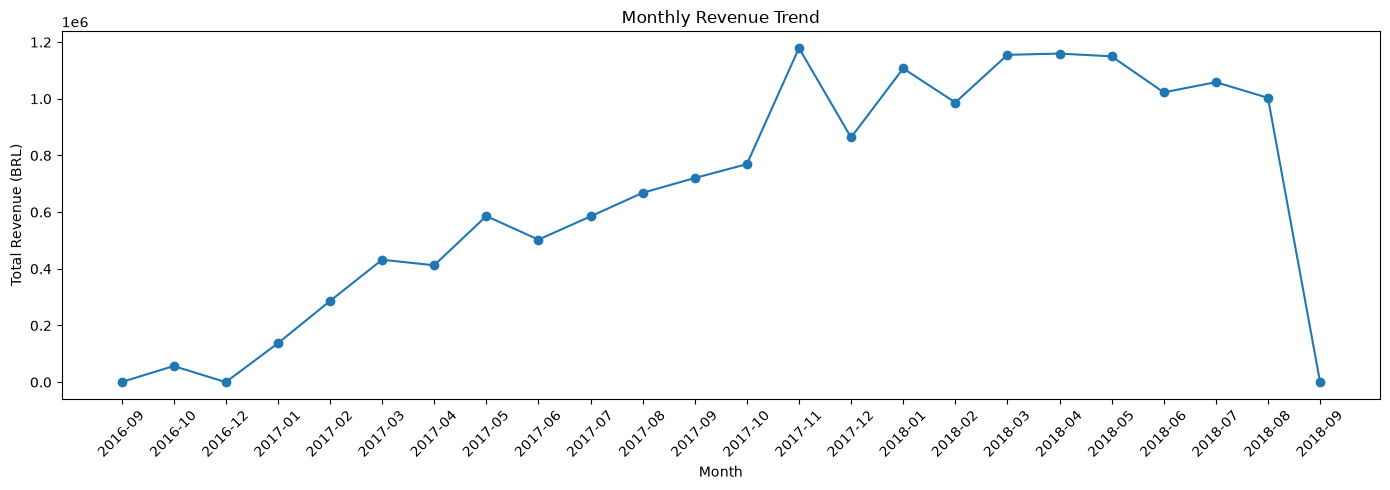

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(trend_data['order_month'], trend_data['total_revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.show()


In [36]:
query = """
SELECT 
    r.review_score,
    DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date) AS delivery_delay_days,
    DATEDIFF(o.order_delivered_customer_date, o.order_purchase_timestamp) AS delivery_time_days,
    p.payment_value,
    p.payment_installments
FROM order_reviews r
JOIN orders o ON r.order_id = o.order_id
JOIN order_payments p ON o.order_id = p.order_id
WHERE o.order_delivered_customer_date IS NOT NULL;
"""

corr_data = pd.read_sql(query, con=engine)
corr_data.head()


,review_score,delivery_delay_days,delivery_time_days,payment_value,payment_installments
0,5,-9,7,72.19,2
1,4,-3,16,259.83,3
2,5,-14,8,216.87,5
3,4,-6,6,25.78,2
4,5,-16,25,218.04,3


In [37]:
correlation_matrix = corr_data.corr()
print(correlation_matrix)

                      review_score  delivery_delay_days  delivery_time_days  \
review_score              1.000000            -0.265737           -0.332108   
delivery_delay_days      -0.265737             1.000000            0.601714   
delivery_time_days       -0.332108             0.601714            1.000000   
payment_value            -0.040162            -0.017354            0.066957   
payment_installments     -0.028831            -0.029518            0.050512   

                      payment_value  payment_installments  
review_score              -0.040162             -0.028831  
delivery_delay_days       -0.017354             -0.029518  
delivery_time_days         0.066957              0.050512  
payment_value              1.000000              0.332165  
payment_installments       0.332165              1.000000  


In [38]:
query = "SELECT payment_value FROM order_payments;"
payments = pd.read_sql(query, con=engine)

print(payments['payment_value'].describe())
print("\nSkewness:", payments['payment_value'].skew())

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Skewness: 9.254009528478061


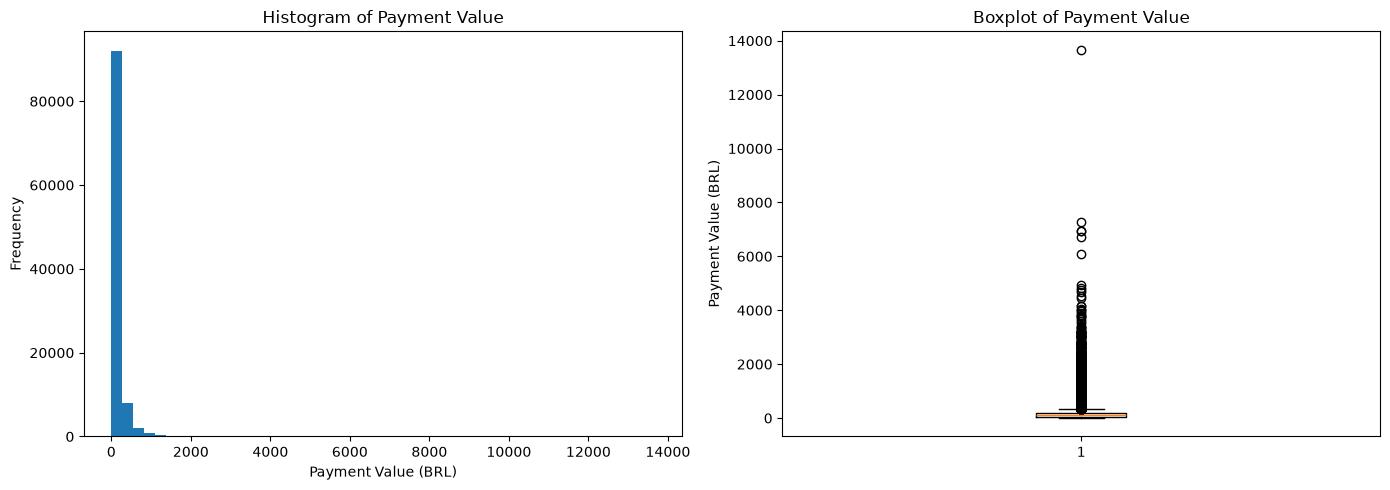

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(payments['payment_value'], bins=50)
axes[0].set_title('Histogram of Payment Value')
axes[0].set_xlabel('Payment Value (BRL)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(payments['payment_value'])
axes[1].set_title('Boxplot of Payment Value')
axes[1].set_ylabel('Payment Value (BRL)')

plt.tight_layout()
plt.show()